In [3]:
import pandas as pd
import numpy as np
import ast
import torch
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [2]:
import sys

!{sys.executable} -m pip install pandas scikit-learn matplotlib torch transformers accelerate

In [4]:
csv_path = "FINAL_BALANCED_FOR_M3.csv"

raw_df = pd.read_csv(csv_path)

print("Dataset shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())

display(raw_df.head())

Dataset shape: (683532, 4)
Columns: ['review_type', 'review_content', 'pos_tags', 'lemmatized']


,review_type,review_content,pos_tags,lemmatized
0,Rotten,A very disappointing version of the classic st...,"[('a', 'DT'), ('very', 'RB'), ('disappointing'...","['disappointing', 'version', 'classic', 'stage..."
1,Rotten,"As expected, the soundtrack is the highlight o...","[('as', 'IN'), ('expected', 'VBN'), (',', ',')...","['expect', 'soundtrack', 'highlight', 'idlewil..."
2,Fresh,It's a personal and profound work.,"[('it', 'PRP'), ('is', 'VBZ'), ('a', 'DT'), ('...","['personal', 'profound', 'work']"
3,Fresh,"a deftly paced, expertly performed character s...","[('a', 'DT'), ('deftly', 'RB'), ('paced', 'VBN...","['deftly', 'pace', 'expertly', 'perform', 'cha..."
4,Fresh,So what if it's sheer petty escapist enjoyment...,"[('so', 'RB'), ('what', 'WP'), ('if', 'IN'), (...","['sheer', 'petty', 'escapist', 'enjoyment', 't..."


In [5]:
print("Missing values:")
print(raw_df.isnull().sum())

print("\nReview type distribution:")
print(raw_df["review_type"].value_counts())

print("\nDataset preview:")
display(raw_df.head())

Missing values:
review_type       0
review_content    0
pos_tags          0
lemmatized        0
dtype: int64

Review type distribution:
review_type
Rotten    341766
Fresh     341766
Name: count, dtype: int64

Dataset preview:


,review_type,review_content,pos_tags,lemmatized
0,Rotten,A very disappointing version of the classic st...,"[('a', 'DT'), ('very', 'RB'), ('disappointing'...","['disappointing', 'version', 'classic', 'stage..."
1,Rotten,"As expected, the soundtrack is the highlight o...","[('as', 'IN'), ('expected', 'VBN'), (',', ',')...","['expect', 'soundtrack', 'highlight', 'idlewil..."
2,Fresh,It's a personal and profound work.,"[('it', 'PRP'), ('is', 'VBZ'), ('a', 'DT'), ('...","['personal', 'profound', 'work']"
3,Fresh,"a deftly paced, expertly performed character s...","[('a', 'DT'), ('deftly', 'RB'), ('paced', 'VBN...","['deftly', 'pace', 'expertly', 'perform', 'cha..."
4,Fresh,So what if it's sheer petty escapist enjoyment...,"[('so', 'RB'), ('what', 'WP'), ('if', 'IN'), (...","['sheer', 'petty', 'escapist', 'enjoyment', 't..."


In [6]:
df_bert = raw_df[["review_content", "review_type"]].dropna().copy()

df_bert["review_content"] = df_bert["review_content"].astype(str)
df_bert["review_type"] = df_bert["review_type"].astype(str).str.strip()

# Keep only Fresh and Rotten labels
df_bert = df_bert[df_bert["review_type"].isin(["Fresh", "Rotten"])]

print("Final BERT dataset shape:", df_bert.shape)
print(df_bert["review_type"].value_counts())

display(df_bert.head())

Final BERT dataset shape: (683532, 2)
review_type
Rotten    341766
Fresh     341766
Name: count, dtype: int64


,review_content,review_type
0,A very disappointing version of the classic st...,Rotten
1,"As expected, the soundtrack is the highlight o...",Rotten
2,It's a personal and profound work.,Fresh
3,"a deftly paced, expertly performed character s...",Fresh
4,So what if it's sheer petty escapist enjoyment...,Fresh


In [7]:
X = df_bert["review_content"]
y = df_bert["review_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training size: 546825
Testing size: 136707

Training label distribution:
review_type
Rotten    273413
Fresh     273412
Name: count, dtype: int64

Testing label distribution:
review_type
Fresh     68354
Rotten    68353
Name: count, dtype: int64


In [8]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

Label mapping:
0 = Fresh
1 = Rotten


In [9]:
train_sample_size = 5000
test_sample_size = 1000

X_train_small = X_train.sample(
    n=min(train_sample_size, len(X_train)),
    random_state=42
)

y_train_small = y_train.loc[X_train_small.index]

X_test_small = X_test.sample(
    n=min(test_sample_size, len(X_test)),
    random_state=42
)

y_test_small = y_test.loc[X_test_small.index]

y_train_small_encoded = label_encoder.transform(y_train_small)
y_test_small_encoded = label_encoder.transform(y_test_small)

print("Small training size:", len(X_train_small))
print("Small testing size:", len(X_test_small))

print("\nSmall training distribution:")
print(y_train_small.value_counts())

print("\nSmall testing distribution:")
print(y_test_small.value_counts())

Small training size: 5000
Small testing size: 1000

Small training distribution:
review_type
Fresh     2530
Rotten    2470
Name: count, dtype: int64

Small testing distribution:
review_type
Rotten    528
Fresh     472
Name: count, dtype: int64


In [10]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU. Training may be slower.")

CUDA available: False
Using CPU. Training may be slower.


In [11]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    X_train_small.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test_small.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization completed.")

Tokenization completed.


In [12]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = ReviewDataset(train_encodings, y_train_small_encoded)
test_dataset = ReviewDataset(test_encodings, y_test_small_encoded)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 5000
Test dataset size: 1000


In [13]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("BERT model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded.


In [15]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [16]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=2,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_dir="./bert_logs",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.475679,0.363630,0.849000,0.849353,0.849000,0.848724
2,0.235906,0.576344,0.836000,0.835969,0.836000,0.835981


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1250, training_loss=0.37786919174194333, metrics={'train_runtime': 38701.6374, 'train_samples_per_second': 0.258, 'train_steps_per_second': 0.032, 'total_flos': 375138809400000.0, 'train_loss': 0.37786919174194333, 'epoch': 2.0})

In [17]:
bert_results = trainer.evaluate()

print("BERT Evaluation Results:")
print(bert_results)

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.235906,0.363014,2,0.850000,0.850311,0.850000,0.849741


BERT Evaluation Results:
{'eval_loss': 0.36301445960998535, 'eval_accuracy': 0.85, 'eval_precision': 0.8503111111111111, 'eval_recall': 0.85, 'eval_f1': 0.8497410243924035}


In [18]:
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)

print("Classification Report:")
print(classification_report(
    y_test_small_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification Report:
              precision    recall  f1-score   support

       Fresh       0.86      0.82      0.84       472
      Rotten       0.84      0.88      0.86       528

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



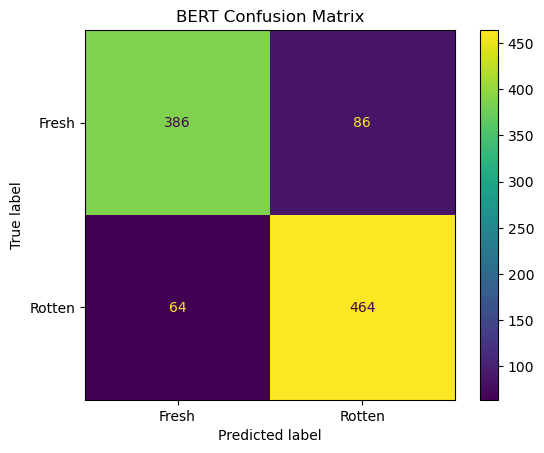

In [19]:
cm = confusion_matrix(y_test_small_encoded, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("BERT Confusion Matrix")
plt.show()

In [20]:
trainer.save_model("./bert_sentiment_model")
tokenizer.save_pretrained("./bert_sentiment_model")

print("BERT model saved successfully in './bert_sentiment_model'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved successfully in './bert_sentiment_model'


In [21]:
bert_summary = pd.DataFrame([{
    "model": "BERT",
    "train_sample_size": len(X_train_small),
    "test_sample_size": len(X_test_small),
    "accuracy": bert_results.get("eval_accuracy"),
    "precision": bert_results.get("eval_precision"),
    "recall": bert_results.get("eval_recall"),
    "f1": bert_results.get("eval_f1")
}])

display(bert_summary)

bert_summary.to_csv("bert_evaluation_summary.csv", index=False)

print("BERT evaluation summary saved as bert_evaluation_summary.csv")

,model,train_sample_size,test_sample_size,accuracy,precision,recall,f1
0,BERT,5000,1000,0.85,0.850311,0.85,0.849741


BERT evaluation summary saved as bert_evaluation_summary.csv


In [22]:
print("Columns available:")
print(raw_df.columns.tolist())

if "pos_tags" in raw_df.columns:
    print("\npos_tags column found.")
    print("\nExample pos_tags value:")
    print(raw_df["pos_tags"].dropna().iloc[0])
else:
    print("\npos_tags column not found. ABSA cannot be done using POS tags.")

Columns available:
['review_type', 'review_content', 'pos_tags', 'lemmatized']

pos_tags column found.

Example pos_tags value:
[('a', 'DT'), ('very', 'RB'), ('disappointing', 'JJ'), ('version', 'NN'), ('of', 'IN'), ('the', 'DT'), ('classic', 'JJ'), ('stage', 'NN'), ('play', 'NN'), ('...', ':')]


In [23]:
required_absa_columns = ["review_content", "review_type", "pos_tags"]

absa_df = raw_df[required_absa_columns].dropna().copy()

absa_df["review_content"] = absa_df["review_content"].astype(str)
absa_df["review_type"] = absa_df["review_type"].astype(str).str.strip()

absa_df = absa_df[absa_df["review_type"].isin(["Fresh", "Rotten"])]

print("ABSA dataset shape:", absa_df.shape)
print(absa_df["review_type"].value_counts())

display(absa_df.head())

ABSA dataset shape: (683532, 3)
review_type
Rotten    341766
Fresh     341766
Name: count, dtype: int64


,review_content,review_type,pos_tags
0,A very disappointing version of the classic st...,Rotten,"[('a', 'DT'), ('very', 'RB'), ('disappointing'..."
1,"As expected, the soundtrack is the highlight o...",Rotten,"[('as', 'IN'), ('expected', 'VBN'), (',', ',')..."
2,It's a personal and profound work.,Fresh,"[('it', 'PRP'), ('is', 'VBZ'), ('a', 'DT'), ('..."
3,"a deftly paced, expertly performed character s...",Fresh,"[('a', 'DT'), ('deftly', 'RB'), ('paced', 'VBN..."
4,So what if it's sheer petty escapist enjoyment...,Fresh,"[('so', 'RB'), ('what', 'WP'), ('if', 'IN'), (..."


In [24]:
def safe_parse_pos_tags(pos_value):
    if isinstance(pos_value, list):
        return pos_value

    if isinstance(pos_value, str):
        try:
            return ast.literal_eval(pos_value)
        except:
            return []

    return []

In [25]:
def extract_adj_noun_from_pos(pos_tags):
    tags = safe_parse_pos_tags(pos_tags)
    pairs = []

    for i in range(len(tags) - 1):
        try:
            current_word, current_pos = tags[i]
            next_word, next_pos = tags[i + 1]

            if current_pos.startswith("JJ") and next_pos.startswith("NN"):
                pairs.append((current_word.lower(), next_word.lower()))

        except:
            continue

    return pairs

In [26]:
sample_pos = absa_df["pos_tags"].iloc[0]

print("Original POS tags:")
print(sample_pos)

print("\nExtracted aspect-opinion pairs:")
print(extract_adj_noun_from_pos(sample_pos))

Original POS tags:
[('a', 'DT'), ('very', 'RB'), ('disappointing', 'JJ'), ('version', 'NN'), ('of', 'IN'), ('the', 'DT'), ('classic', 'JJ'), ('stage', 'NN'), ('play', 'NN'), ('...', ':')]

Extracted aspect-opinion pairs:
[('disappointing', 'version'), ('classic', 'stage')]


In [27]:
absa_sample_size = 5000

absa_sample = absa_df.sample(
    n=min(absa_sample_size, len(absa_df)),
    random_state=42
).copy()

absa_sample["aspect_opinion_pairs"] = absa_sample["pos_tags"].apply(
    extract_adj_noun_from_pos
)

display(absa_sample[[
    "review_content",
    "review_type",
    "aspect_opinion_pairs"
]].head())

,review_content,review_type,aspect_opinion_pairs
645435,Shyamalan is a master at a visual iconic momen...,Rotten,"[(iconic, moment), (english, class)]"
658269,What did Sweden ever do to anyone to deserve t...,Rotten,[]
30684,"All in all, it's hard to know for whom ""Hop"" i...",Rotten,[]
327541,The Aristocrats might have made a nice short s...,Rotten,"[(short, subject)]"
193529,"The story and the animation are fairly simple,...",Fresh,"[(latin, rhythms)]"


In [28]:
all_pairs = []

for pairs in absa_sample["aspect_opinion_pairs"]:
    all_pairs.extend(pairs)

pair_counts = Counter(all_pairs)

absa_results = pd.DataFrame(
    pair_counts.items(),
    columns=["aspect_opinion_pair", "count"]
)

if len(absa_results) > 0:
    absa_results[["opinion", "aspect"]] = pd.DataFrame(
        absa_results["aspect_opinion_pair"].tolist(),
        index=absa_results.index
    )

    absa_results = absa_results[["aspect", "opinion", "count"]]
    absa_results = absa_results.sort_values(by="count", ascending=False)
else:
    absa_results = pd.DataFrame(columns=["aspect", "opinion", "count"])

display(absa_results.head(20))

,aspect,opinion,count
40,review,full,86
41,],spanish,85
116,effects,special,17
561,comedy,romantic,17
356,york,new,15
705,film,first,13
1062,screen,big,11
224,story,true,10
1537,time,good,10
2345,films,best,9


In [29]:
fresh_sample = absa_sample[absa_sample["review_type"] == "Fresh"]
rotten_sample = absa_sample[absa_sample["review_type"] == "Rotten"]

def get_pair_count(dataframe):
    all_pairs = []

    for pairs in dataframe["aspect_opinion_pairs"]:
        all_pairs.extend(pairs)

    pair_counts = Counter(all_pairs)

    result = pd.DataFrame(
        pair_counts.items(),
        columns=["aspect_opinion_pair", "count"]
    )

    if len(result) == 0:
        return pd.DataFrame(columns=["aspect", "opinion", "count"])

    result[["opinion", "aspect"]] = pd.DataFrame(
        result["aspect_opinion_pair"].tolist(),
        index=result.index
    )

    result = result[["aspect", "opinion", "count"]]
    result = result.sort_values(by="count", ascending=False)

    return result


fresh_absa = get_pair_count(fresh_sample)
rotten_absa = get_pair_count(rotten_sample)

print("Top Fresh aspect-opinion pairs:")
display(fresh_absa.head(10))

print("Top Rotten aspect-opinion pairs:")
display(rotten_absa.head(10))

Top Fresh aspect-opinion pairs:


,aspect,opinion,count
24,review,full,52
25,],spanish,51
289,comedy,romantic,13
1272,films,best,9
1393,york,new,9
73,effects,special,7
126,story,true,7
387,film,best,6
810,time,good,6
809,film,first,5


Top Rotten aspect-opinion pairs:


,aspect,opinion,count
231,],spanish,34
230,review,full,34
342,effects,special,10
350,film,first,8
416,intentions,good,6
523,screen,big,6
149,york,new,6
857,equivalent,cinematic,5
186,character,main,5
1023,reason,real,5


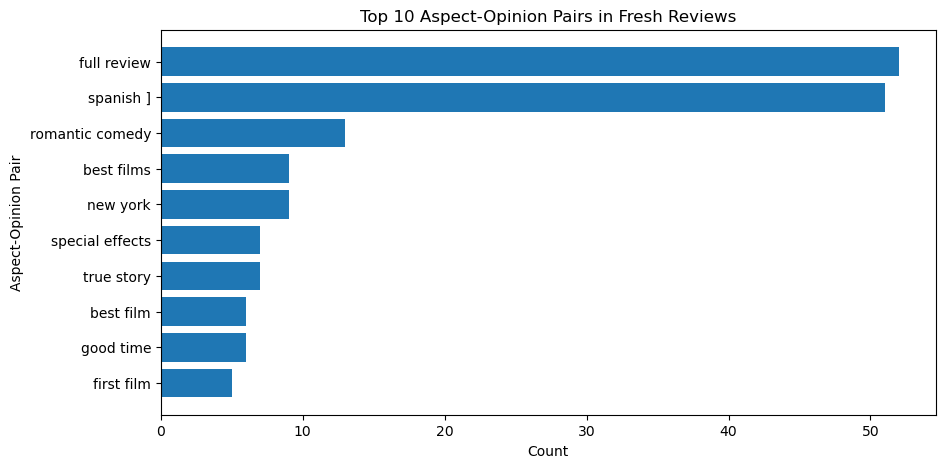

In [30]:
top_fresh = fresh_absa.head(10).copy()

if len(top_fresh) > 0:
    top_fresh["label"] = top_fresh["opinion"] + " " + top_fresh["aspect"]

    plt.figure(figsize=(10, 5))
    plt.barh(top_fresh["label"], top_fresh["count"])
    plt.xlabel("Count")
    plt.ylabel("Aspect-Opinion Pair")
    plt.title("Top 10 Aspect-Opinion Pairs in Fresh Reviews")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("No Fresh ABSA results to plot.")

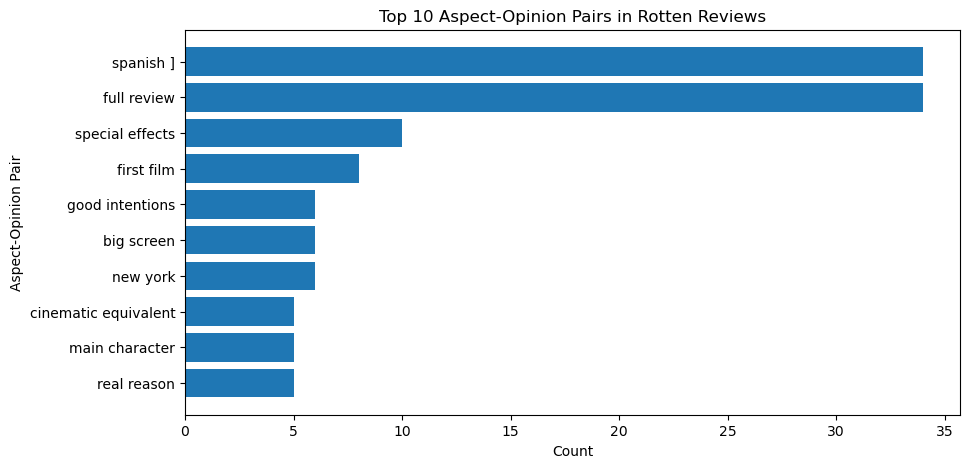

In [31]:
top_rotten = rotten_absa.head(10).copy()

if len(top_rotten) > 0:
    top_rotten["label"] = top_rotten["opinion"] + " " + top_rotten["aspect"]

    plt.figure(figsize=(10, 5))
    plt.barh(top_rotten["label"], top_rotten["count"])
    plt.xlabel("Count")
    plt.ylabel("Aspect-Opinion Pair")
    plt.title("Top 10 Aspect-Opinion Pairs in Rotten Reviews")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("No Rotten ABSA results to plot.")

In [32]:
absa_results.to_csv("all_absa_results.csv", index=False)
fresh_absa.to_csv("fresh_absa_results.csv", index=False)
rotten_absa.to_csv("rotten_absa_results.csv", index=False)

print("ABSA results saved:")
print("- all_absa_results.csv")
print("- fresh_absa_results.csv")
print("- rotten_absa_results.csv")

ABSA results saved:
- all_absa_results.csv
- fresh_absa_results.csv
- rotten_absa_results.csv


In [33]:
print("Member 3 pipeline completed successfully.")

print("\nGenerated outputs:")
print("1. BERT sentiment classification model")
print("2. BERT evaluation summary")
print("3. BERT confusion matrix")
print("4. ABSA aspect-opinion extraction")
print("5. Fresh ABSA results")
print("6. Rotten ABSA results")

print("\nSaved files:")
print("- ./bert_sentiment_model")
print("- bert_evaluation_summary.csv")
print("- all_absa_results.csv")
print("- fresh_absa_results.csv")
print("- rotten_absa_results.csv")

Member 3 pipeline completed successfully.

Generated outputs:
1. BERT sentiment classification model
2. BERT evaluation summary
3. BERT confusion matrix
4. ABSA aspect-opinion extraction
5. Fresh ABSA results
6. Rotten ABSA results

Saved files:
- ./bert_sentiment_model
- bert_evaluation_summary.csv
- all_absa_results.csv
- fresh_absa_results.csv
- rotten_absa_results.csv
